In [2]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    "Train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "Validation",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    "Test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 3455 files belonging to 5 classes.
Found 858 files belonging to 5 classes.
Found 497 files belonging to 5 classes.


In [3]:
import os
print(os.getcwd())

C:\Users\Aamina Rifa\Downloads\datasets_wheat


In [4]:
DATASET_PATH = r"C:\Users\Aamina Rifa\Downloads\datasets_wheat"

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH + "/Train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 3455 files belonging to 5 classes.


In [5]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

In [6]:
from tensorflow.keras import layers

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.1),
])

In [7]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

train_ds = train_ds.map(lambda x,y:(preprocess_input(x),y))
val_ds   = val_ds.map(lambda x,y:(preprocess_input(x),y))
test_ds  = test_ds.map(lambda x,y:(preprocess_input(x),y))

In [8]:
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

In [9]:
x = data_augmentation(base_model.output)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.4)(x)

outputs = layers.Dense(5, activation="softmax")(x)

model = tf.keras.Model(base_model.input, outputs)

In [13]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [14]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=2
)

In [15]:
model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 156s 1s/step - accuracy: 0.9201 - loss: 0.2507 - val_accuracy: 0.9860 - val_loss: 0.0455 - learning_rate: 0.0010
Epoch 2/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 171s 2s/step - accuracy: 0.9849 - loss: 0.0430 - val_accuracy: 0.9918 - val_loss: 0.0223 - learning_rate: 0.0010
Epoch 3/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 173s 1s/step - accuracy: 0.9922 - loss: 0.0209 - val_accuracy: 0.9965 - val_loss: 0.0143 - learning_rate: 0.0010
Epoch 4/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 96s 874ms/step - accuracy: 0.9957 - loss: 0.0142 - val_accuracy: 0.9988 - val_loss: 0.0073 - learning_rate: 0.0010
Epoch 5/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 147s 914ms/step - accuracy: 0.9959 - loss: 0.0128 - val_accuracy: 0.9977 - val_loss: 0.0080 - learning_rate: 0.0010
Epoch 6/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 145s 943ms/step - accuracy: 0.9968 - loss: 0.0096 - val_accuracy: 0.9965 - val_loss: 0.0074 - learning_rate: 0.0010
Epoch 7/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 95s 872ms/step - accuracy: 0.9980 

In [16]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

In [17]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [20]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

In [21]:
model.evaluate(test_ds)

16/16 ━━━━━━━━━━━━━━━━━━━━ 15s 654ms/step - accuracy: 0.9980 - loss: 0.0044


[0.004421533085405827, 0.9979879260063171]

In [23]:
raw_train_ds = tf.keras.utils.image_dataset_from_directory(
    "Train",
    image_size=(224,224),
    batch_size=32
)

class_names = raw_train_ds.class_names
print(class_names)

Found 3455 files belonging to 5 classes.
['BlackPoint', 'FusariumFootRot', 'HealthyLeaf', 'LeafBlight', 'WheatBlast']


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


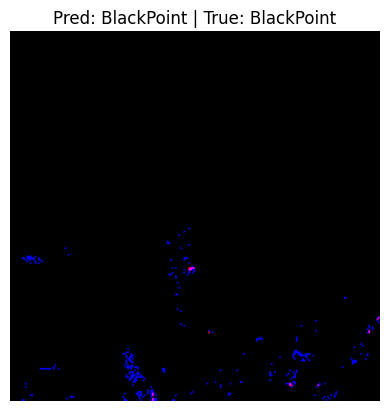

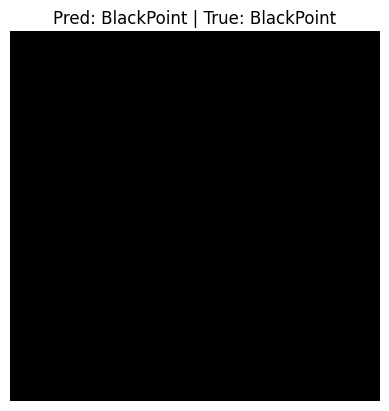

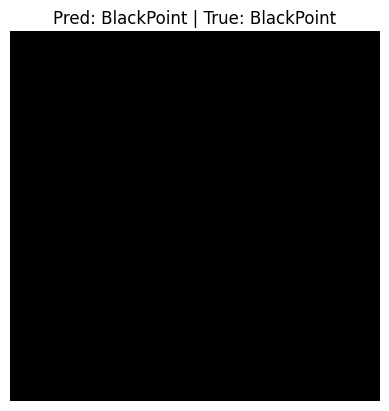

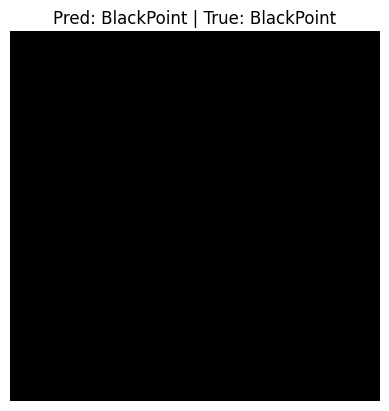

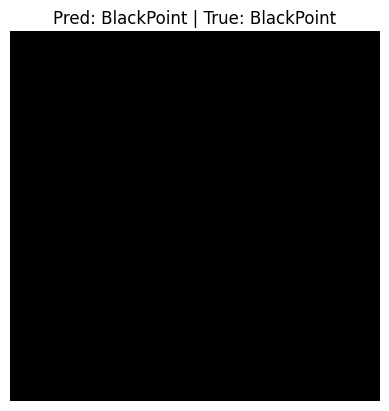

In [24]:
import matplotlib.pyplot as plt
import numpy as np

for images, labels in test_ds.take(1):
    preds = model.predict(images)

    for i in range(5):
        plt.imshow(images[i].numpy().astype("uint8"))
        pred = class_names[np.argmax(preds[i])]
        true = class_names[labels[i]]
        plt.title(f"Pred: {pred} | True: {true}")
        plt.axis("off")
        plt.show()

In [25]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

In [26]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [27]:
model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 151s 1s/step - accuracy: 0.9627 - loss: 0.1112 - val_accuracy: 0.9953 - val_loss: 0.0160 - learning_rate: 1.0000e-05
Epoch 2/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 126s 1s/step - accuracy: 0.9855 - loss: 0.0433 - val_accuracy: 0.9953 - val_loss: 0.0176 - learning_rate: 1.0000e-05
Epoch 3/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 170s 1s/step - accuracy: 0.9884 - loss: 0.0308 - val_accuracy: 0.9953 - val_loss: 0.0159 - learning_rate: 3.0000e-06
Epoch 4/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 182s 1s/step - accuracy: 0.9904 - loss: 0.0246 - val_accuracy: 0.9965 - val_loss: 0.0124 - learning_rate: 3.0000e-06


In [28]:
model.evaluate(test_ds)

16/16 ━━━━━━━━━━━━━━━━━━━━ 11s 612ms/step - accuracy: 0.9960 - loss: 0.0142


[0.01419158186763525, 0.9959758520126343]

In [29]:
model.save("wheat_disease_model.keras")

In [31]:
CLASS_NAMES = [
    "BlackPoint",
    "FusariumFootRot",
    "HealthyLeaf",
    "LeafBlight",
    "WheatBlast"
]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 616ms/step


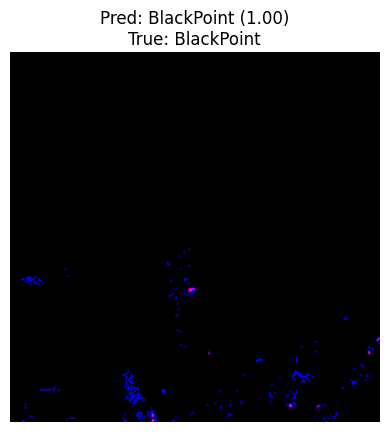

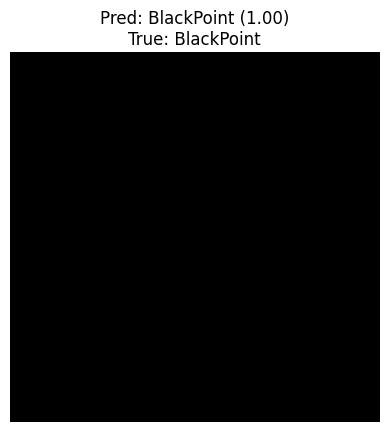

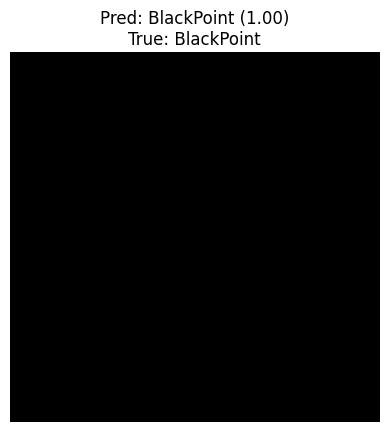

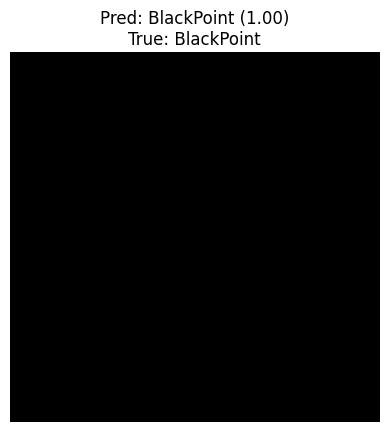

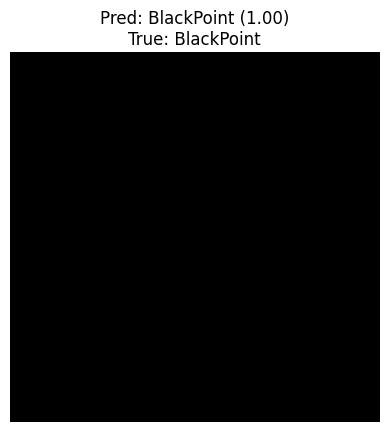

In [32]:
import matplotlib.pyplot as plt
import numpy as np

for images, labels in test_ds.take(1):

    predictions = model.predict(images)

    for i in range(5):
        plt.imshow(images[i].numpy().astype("uint8"))

        predicted_label = CLASS_NAMES[np.argmax(predictions[i])]
        true_label = CLASS_NAMES[labels[i]]

        confidence = np.max(predictions[i])

        plt.title(
            f"Pred: {predicted_label} ({confidence:.2f})\nTrue: {true_label}"
        )

        plt.axis("off")
        plt.show()

In [42]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import entropy

# ===============================
# CLASS NAMES (MUST MATCH TRAINING)
# ===============================
CLASS_NAMES = [
    "BlackPoint",
    "FusariumFootRot",
    "HealthyLeaf",
    "LeafBlight",
    "WheatBlast"
]

# ===============================
# SMART THRESHOLDS
# ===============================
CONF_THRESHOLD = 0.85        # stricter confidence
ENTROPY_THRESHOLD = 0.80     # uncertainty control


def predict_wheat_image(img_path):

    # ---------- Load Image ----------
    img = Image.open(img_path).convert("RGB")
    img = img.resize((224, 224))

    plt.imshow(img)
    plt.title("Input Image")
    plt.axis("off")
    plt.show()

    # ---------- Preprocess ----------
    img_array = np.array(img)
    img_array = preprocess_input(img_array)
    img_array = np.expand_dims(img_array, axis=0)

    # ---------- Prediction ----------
    prediction = model.predict(img_array, verbose=0)[0]

    confidence = float(np.max(prediction))
    predicted_index = int(np.argmax(prediction))
    predicted_class = CLASS_NAMES[predicted_index]

    # safer entropy
    ent = float(entropy(prediction + 1e-10))

    # ---------- Decision Logic ----------
    print("\nPrediction Probabilities:")
    for i, prob in enumerate(prediction):
        print(f"{CLASS_NAMES[i]} : {prob:.3f}")

    print("\n----------------------------")

    if confidence < CONF_THRESHOLD or ent > ENTROPY_THRESHOLD:
        print("⚠ RESULT : Not a Wheat Leaf / Unknown Image")
    else:
        print("✅ Disease Detected :", predicted_class)

    print("Confidence :", round(confidence, 3))
    print("Entropy    :", round(ent, 3))

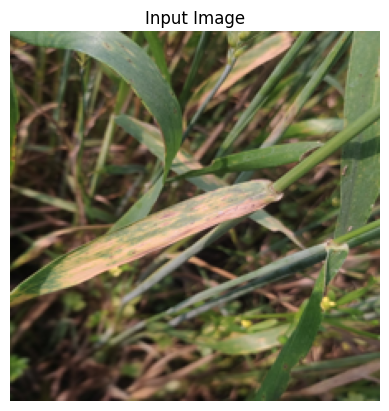


Prediction Probabilities:
BlackPoint : 0.000
FusariumFootRot : 0.000
HealthyLeaf : 0.000
LeafBlight : 1.000
WheatBlast : 0.000

----------------------------
✅ Disease Detected : LeafBlight
Confidence : 1.0
Entropy    : 0.0


In [46]:
predict_wheat_image(
r"C:\Users\Aamina Rifa\Downloads\wheat-disease\Wheat Leaf Disease\Test\LeafBlight\center_scaled_1.3_451.jpg"
)


In [47]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1 (Conv2D)                │ (None, 112, 112, 32)      │             864 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bn_Conv1 (BatchNormalization) │ (None, 112, 112, 32)      │             128 │ Conv1[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1_relu (ReLU)             │ (None, 112, 112, 32)      │               0 │ bn_Conv1[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise       │ (None, 112, 112, 32)      │             288 │ Conv1_relu[0][0]           │
│ (DepthwiseConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_BN    │ (None, 112, 112, 32)      │             128 │ expanded_conv_depthwise[0… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_relu  │ (None, 112, 112, 32)      │               0 │ expanded_conv_depthwise_B… │
│ (ReLU)                        │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project         │ (None, 112, 112, 16)      │             512 │ expanded_conv_depthwise_r… │
│ (Conv2D)                      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project_BN      │ (None, 112, 112, 16)      │              64 │ expanded_conv_project[0][… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand (Conv2D)       │ (None, 112, 112, 96)      │           1,536 │ expanded_conv_project_BN[… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_BN             │ (None, 112, 112, 96)      │             384 │ block_1_expand[0][0]       │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_relu (ReLU)    │ (None, 112, 112, 96)      │               0 │ block_1_expand_BN[0][0]    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_pad (ZeroPadding2D)   │ (None, 113, 113, 96)      │               0 │ block_1_expand_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_depthwise             │ (None, 56, 56, 96)        │             864 │ block_1_pad[0][0]          │
│ (DepthwiseConv2D)             │                           │               

 Total params: 5,814,865 (22.18 MB)

 Trainable params: 1,693,573 (6.46 MB)

 Non-trainable params: 734,144 (2.80 MB)

 Optimizer params: 3,387,148 (12.92 MB)

In [48]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
import numpy as np

def predict(model, img, class_names):

    # resize (safety)
    img = tf.image.resize(img, (224,224))

    # preprocess exactly like training
    img = preprocess_input(img)

    img = np.expand_dims(img, axis=0)

    prediction = model.predict(img, verbose=0)[0]

    predicted_index = np.argmax(prediction)
    predicted_class = class_names[predicted_index]
    confidence = round(100 * np.max(prediction), 2)

    return predicted_class, confidence

In [49]:
class_names = [
    "BlackPoint",
    "FusariumFootRot",
    "HealthyLeaf",
    "LeafBlight",
    "WheatBlast"
]

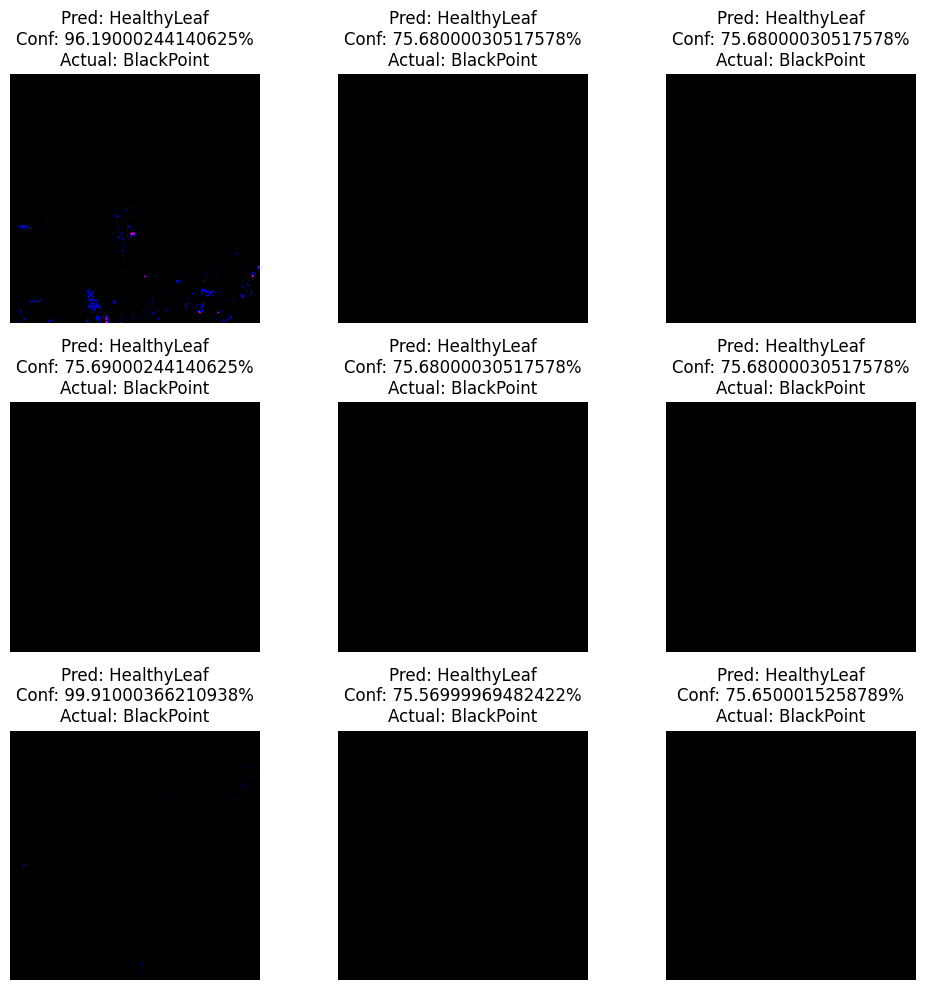

In [50]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))

for images_batch, labels_batch in test_ds.take(1):

    for i in range(9):

        ax = plt.subplot(3, 3, i + 1)

        img = images_batch[i].numpy().astype("uint8")

        actual_label = class_names[labels_batch[i].numpy()]

        predicted_class, confidence = predict(
            model,
            img,
            class_names
        )

        plt.imshow(img)
        plt.title(
            f"Pred: {predicted_class}\n"
            f"Conf: {confidence}%\n"
            f"Actual: {actual_label}"
        )

        plt.axis("off")

plt.tight_layout()
plt.show()